In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
#data
x=torch.arange(1,10,dtype=torch.float32).reshape(-1,1)
x

tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])

In [3]:
y=2*x

In [4]:
# Adam hyperparameters
beta1 = 0.9
beta2 = 0.999
lr = 0.01
epsilon = 1e-8


In [5]:
# Adam variables
m=0.0
v=0.0

In [6]:
# Initial weight
w=torch.tensor(0.0,requires_grad=True)
w

tensor(0., requires_grad=True)

In [7]:
# history
loss_history=[]


For 1 loss is 126.66666412353516
For 2 loss is 125.40316772460938
For 3 loss is 124.14615631103516
For 4 loss is 122.89578247070312
For 5 loss is 121.65211486816406
For 6 loss is 120.41526794433594
For 7 loss is 119.18534088134766
For 8 loss is 117.96244049072266
For 9 loss is 116.74666595458984
For 10 loss is 115.53811645507812
For 11 loss is 114.33684539794922
For 12 loss is 113.14299774169922
For 13 loss is 111.95660400390625
For 14 loss is 110.77776336669922
For 15 loss is 109.6065673828125
For 16 loss is 108.44306182861328
For 17 loss is 107.28732299804688
For 18 loss is 106.13941955566406
For 19 loss is 104.99939727783203
For 20 loss is 103.86731719970703
For 21 loss is 102.74323272705078
For 22 loss is 101.62718200683594
For 23 loss is 100.51921081542969
For 24 loss is 99.41936492919922
For 25 loss is 98.32766723632812
For 26 loss is 97.244140625
For 27 loss is 96.1688232421875
For 28 loss is 95.10173797607422
For 29 loss is 94.04291534423828
For 30 loss is 92.99234008789062
For

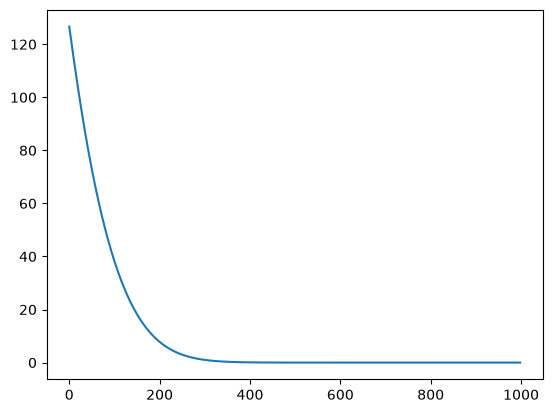

In [8]:
for t in range(1,1000):
    #Forwared propagation
    y_pred=w*x
    
    #MSE
    loss=torch.mean((y_pred-y)**2)
    
    # Backpropagation
    loss.backward()
    
    #Gradient
    grad=w.grad.item()
    
    # First moment
    m=m*beta1+(1-beta1)*grad
    
    # Second moment
    v=v*beta2+(1-beta2)*grad**2
    
    #Bias correction
    m_hat=m/(1-(beta1)**t)
    v_hat=v/(1-(beta2)**t)
    
    with torch.no_grad():
        w-=lr*m_hat/(torch.sqrt(torch.tensor(v_hat))+epsilon)
        
    w.grad.zero_()
    loss_history.append(loss.item())
    print(f"For {t} loss is {loss}")
plt.plot(loss_history)
plt.show()

RMS(Root Mean Square)Prop

In [9]:
rmse_history = []
for t in range(1, 1000):

    # Forward propagation
    y_pred = w * x

    # MSE
    mse = torch.mean((y_pred - y) ** 2)

    # RMSE
    rmse = torch.sqrt(mse)

    # Backpropagation
    mse.backward()

    # Gradient
    grad = w.grad.item()

    # RMSProp
    v = beta1* v + (1 - beta1) * grad ** 2

    # Weight update
    with torch.no_grad():
        w -= lr * grad / (
            torch.sqrt(torch.tensor(v)) + epsilon
        )

    # Clear gradient
    w.grad.zero_()

    # Store RMSE
    rmse_history.append(rmse.item())

    if t % 100 == 0:
        print(
            f"Iteration: {t}, "
            f"RMSE: {rmse.item():.6f}, "
            f"Weight: {w.item():.6f}"
        )

Iteration: 100, RMSE: 0.000000, Weight: 2.000000
Iteration: 200, RMSE: 0.000000, Weight: 2.000000
Iteration: 300, RMSE: 0.000000, Weight: 2.000000
Iteration: 400, RMSE: 0.000000, Weight: 2.000000
Iteration: 500, RMSE: 0.000000, Weight: 2.000000
Iteration: 600, RMSE: 0.000000, Weight: 2.000000
Iteration: 700, RMSE: 0.000000, Weight: 2.000000
Iteration: 800, RMSE: 0.000000, Weight: 2.000000
Iteration: 900, RMSE: 0.000000, Weight: 2.000000


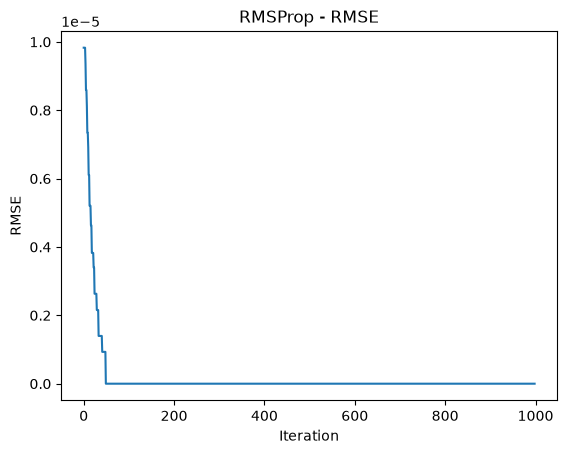

In [10]:
plt.plot(rmse_history)
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("RMSProp - RMSE")
plt.show()